<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Decesion_Tree1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Hospital_Readmission_Prediction (1).csv to Hospital_Readmission_Prediction (1).csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Hospital_Readmission_Prediction (1).csv")

In [5]:
df.head()

,Patient_Age,Hospital_Stay_Days,Previous_Admissions,Chronic_Conditions,Followup_Visits_Missed,Readmission
0,69,18,6,0,2,No
1,32,5,2,5,9,Yes
2,89,13,2,2,8,Yes
3,78,4,6,2,8,Yes
4,38,17,3,2,9,Yes


In [6]:
df.shape

(2000, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Patient_Age             2000 non-null   int64 
 1   Hospital_Stay_Days      2000 non-null   int64 
 2   Previous_Admissions     2000 non-null   int64 
 3   Chronic_Conditions      2000 non-null   int64 
 4   Followup_Visits_Missed  2000 non-null   int64 
 5   Readmission             2000 non-null   object
dtypes: int64(5), object(1)
memory usage: 93.9+ KB


In [8]:
df.describe()

,Patient_Age,Hospital_Stay_Days,Previous_Admissions,Chronic_Conditions,Followup_Visits_Missed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.682500,10.128000,3.623500,2.465000,4.553500
std,20.843006,5.520132,2.268991,1.710333,2.949659
min,18.000000,1.000000,0.000000,0.000000,0.000000
25%,34.000000,5.000000,2.000000,1.000000,2.000000
50%,52.000000,10.000000,4.000000,2.000000,5.000000
75%,71.000000,15.000000,6.000000,4.000000,7.000000
max,89.000000,19.000000,7.000000,5.000000,9.000000


In [9]:
df["Readmission"].value_counts()

,count
Readmission,
Yes,1046
No,954


In [10]:
df["Readmission"] = df["Readmission"].map({
    "No":0,
    "Yes":1
})

In [11]:
df["Readmission"].value_counts()

,count
Readmission,
1,1046
0,954


In [12]:
X = df[
    [
        "Patient_Age",
        "Hospital_Stay_Days",
        "Previous_Admissions",
        "Chronic_Conditions",
        "Followup_Visits_Missed"
    ]
]

In [13]:
y = df["Readmission"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

In [16]:
model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [17]:
y_pred = model.predict(
    X_test
)

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 86.0 %


In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[154  30]
 [ 26 190]]


In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       184
           1       0.86      0.88      0.87       216

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [21]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Followup_Visits_Missed,0.355618
3,Chronic_Conditions,0.301949
2,Previous_Admissions,0.275265
1,Hospital_Stay_Days,0.067169
0,Patient_Age,0.000000


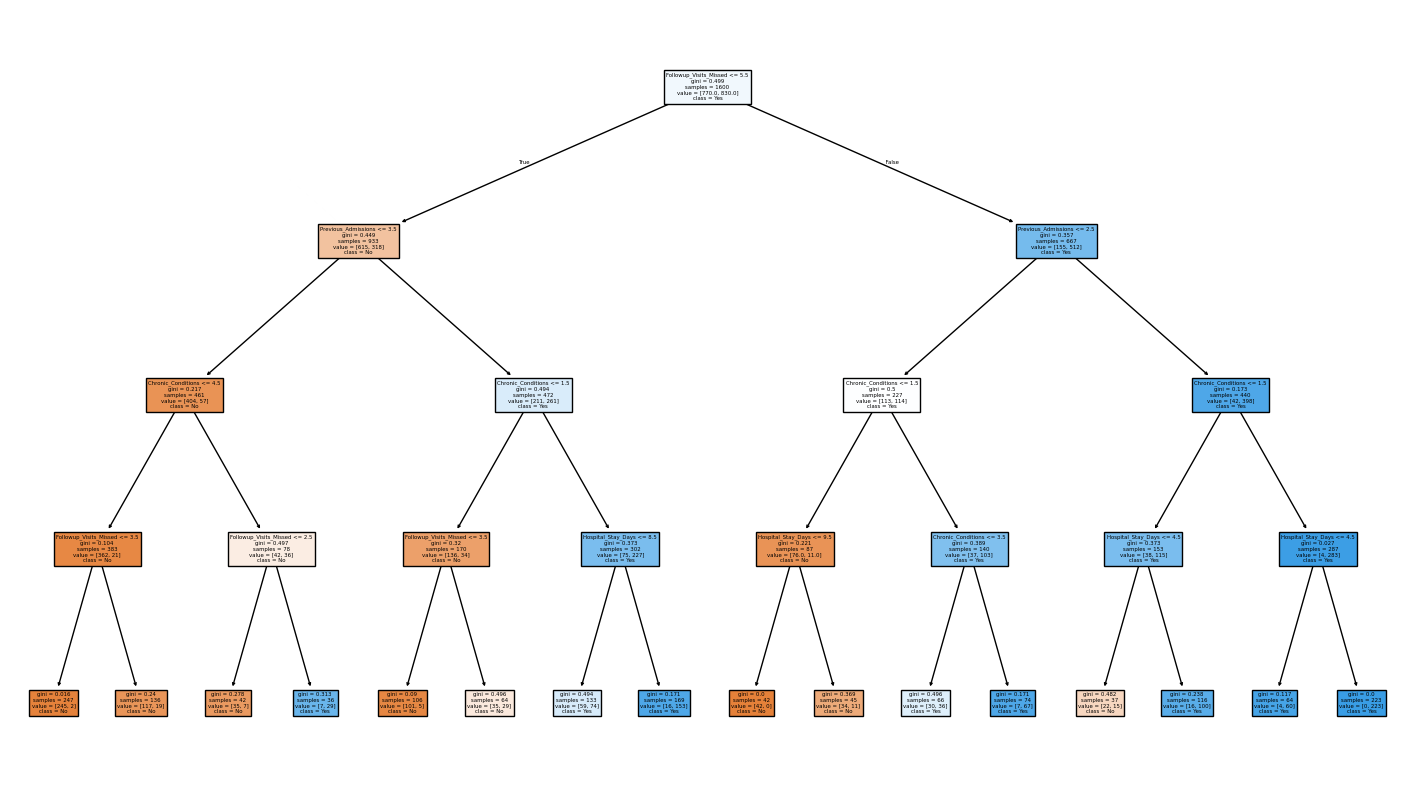

In [22]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [23]:
train_accuracy = model.score(
    X_train,
    y_train
)

print(
    "Training Accuracy:",
    train_accuracy
)

Training Accuracy: 0.858125


In [24]:
test_accuracy = model.score(
    X_test,
    y_test
)

print(
    "Testing Accuracy:",
    test_accuracy
)

Testing Accuracy: 0.86


In [25]:
# Age = 65

# Hospital Stay = 12 Days

# Previous Admissions = 4

# Chronic Conditions = 3

# Missed Followups = 5

new_patient = pd.DataFrame({
    "Patient_Age":[65],
    "Hospital_Stay_Days":[12],
    "Previous_Admissions":[4],
    "Chronic_Conditions":[3],
    "Followup_Visits_Missed":[5]
})

prediction = model.predict(
    new_patient
)

print(prediction)

[1]


In [26]:
model.predict_proba(
    new_patient
)

array([[0.09467456, 0.90532544]])